In [25]:
import pandas as pd
import pandahouse as ph
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

#параметры соединения - нужны, чтобы подключиться к нужной схеме данных
connection = {'host': 'http://clickhouse.lab.karpov.courses:8123',
'database':'simulator_20260820',
'user':'student',
'password':'dpo_python_2020'
}

#текст запроса
query = """
SELECT exp_group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM {db}.feed_actions 
WHERE toDate(time) between '2026-07-31' and '2026-08-06'
    and exp_group in (1,2)
GROUP BY exp_group, user_id
"""

# Записываем данные в DataFrame
df = ph.read_clickhouse(query, connection=connection)

#Группируем по exp_group и сравниваем размеры
df.groupby('exp_group').count()

,user_id,likes,views,ctr
exp_group,,,,
1,10020,10020,10020,10020
2,9877,9877,9877,9877


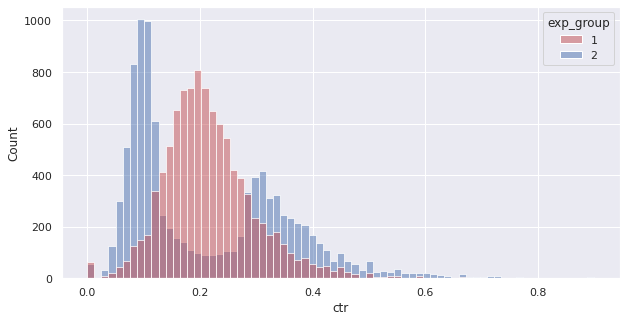

In [5]:
# Распределение в seaborn
sns.set(rc={'figure.figsize':(10,5)})

groups = sns.histplot(data = df, 
              x='ctr', 
              hue='exp_group', 
              palette = ['r', 'b'],
              alpha=0.5,
              kde=False)

Первая группа имеет нормальное распределение.  
У второй группы распределение не нормальное с выраженным скосом вправо.

In [6]:
# Проверка датафрейма
print('Проверка на пропуски', df.isna().sum(), sep='\n')
print('Проверка на дубликаты', df.duplicated().sum(), sep='\n')

# Основные статистики
df.groupby('exp_group')['ctr'].describe()

Проверка на пропуски
exp_group    0
user_id      0
likes        0
views        0
ctr          0
dtype: int64
Проверка на дубликаты
0


,count,mean,std,min,25%,50%,75%,max
exp_group,,,,,,,,
1,10020.0,0.216774,0.082969,0.0,0.163636,0.205882,0.257870,0.722222
2,9877.0,0.216102,0.142870,0.0,0.096774,0.153285,0.323529,0.900000


In [4]:
# Т-тест

control = df[df.exp_group == 1]['ctr']
test = df[df.exp_group == 2]['ctr']

print(stats.ttest_ind(control, test, equal_var=False))
print('Среднее контрольной:', control.mean())
print('Среднее тестовой:', test.mean())

Ttest_indResult(statistic=0.4051491913112757, pvalue=0.685373331140751)
Среднее контрольной: 0.216773994120072
Среднее тестовой: 0.2161016893237817


Не отвергаем нулевую гипотезу о равенстве средних. Т-тест не показал значимых различий.  
Видим, что средние этих выборок почти равны. Т-тест здесь не оптимален т.к. распределение второй группы далеко от нормального и на скошенных данных T-тест теряет чувствительность.

In [8]:
# U-тест Манна Уитни

print(stats.mannwhitneyu(control, test, alternative='two-sided'))

# Вероятность того, что случайно выбранное значение контрольной группы, больше чем тестовой (CLES)
A_gt_B = 0
for _ in range(10000):
    A_gt_B+= control.sample().values[0] > test.sample().values[0]
    
print('В', A_gt_B/100, '% случаев A > B')
#Разница медиан
print(f"Группа A (контрольная): медиана={np.median(control)}")
print(f"Группа B (тестовая): медиана={np.median(test)}")

MannwhitneyuResult(statistic=55189913.0, pvalue=4.632205841806026e-45)
В 55.32 % случаев A > B
Группа A (контрольная): медиана=0.2058823529411764
Группа B (тестовая): медиана=0.1532846715328467


Тест Манна Уитни показал значимое различие между группами. Нулевую гипотезу отвергаем. P(X>Y)!=P(Y>X)  
CLES показал, что случайное значение из контрольной группы в 55% случаев превышает случайное значение из тестовой группы.
Медианное значение целевой метрики в контрольной группе (0.205) выше, чем в тестовой (0.153). Падение метрики по медиане составляет 33%~

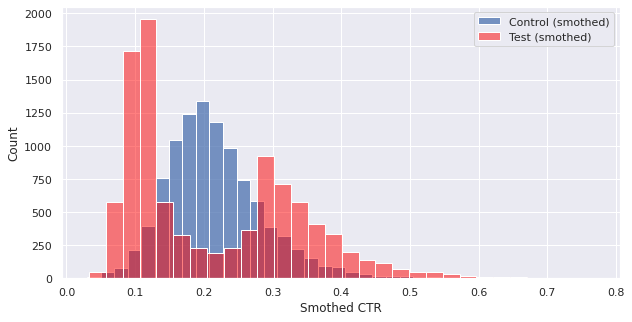

Ttest_indResult(statistic=1.2447034376197188, pvalue=0.2132595139151033)


In [86]:
# Сглаженный CTR

def get_smothed_ctr(user_likes, user_views, global_ctr, alpha):
    smothed_ctr = (user_likes + alpha * global_ctr) / (user_views + alpha)
    return smothed_ctr

global_ctr_1 = df[df.exp_group == 1].likes.sum()/df[df.exp_group == 1].views.sum()
global_ctr_2 = df[df.exp_group == 2].likes.sum()/df[df.exp_group == 2].views.sum()

smothed_control = df[df.exp_group == 1].copy()
smothed_test = df[df.exp_group == 2].copy()

smothed_control['smothed_ctr'] = smothed_control.apply(
    lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_1, 5), axis=1)
smothed_test['smothed_ctr'] = smothed_test.apply(
    lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_1, 5), axis=1)

sns.histplot(smothed_control['smothed_ctr'], 
             kde=False,
             label='Control (smothed)',
             bins=30)
sns.histplot(smothed_test['smothed_ctr'], 
             kde=False,
             alpha=0.5,
             label='Test (smothed)',
             color ='red',
             bins=30)
plt.legend()
plt.xlabel('Smothed CTR')
plt.show()

print(stats.ttest_ind(smothed_control['smothed_ctr'], smothed_test['smothed_ctr'], equal_var=False))

Т-тест на сглаженных CTR не выявил статистически значимых отличий. Не отвергаем нулевую гипотезу.

Text(0, 0.5, 'Частота')

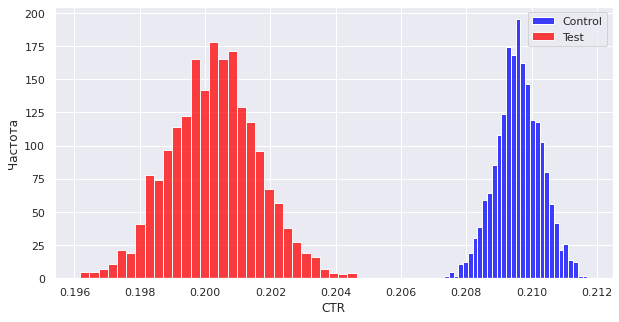

In [12]:
# Пуассоновский бутстрап

def bootstrap(likes1, views1, likes2, views2, n_bootstrap=2000):

    poisson_bootstraps1 = stats.poisson(1).rvs(
        (n_bootstrap, len(likes1))).astype(np.int64)

    poisson_bootstraps2 = stats.poisson(1).rvs(
            (n_bootstrap, len(likes2))).astype(np.int64)
    
    globalCTR1 = (poisson_bootstraps1*likes1).sum(axis=1)/(poisson_bootstraps1*views1).sum(axis=1)
    
    globalCTR2 = (poisson_bootstraps2*likes2).sum(axis=1)/(poisson_bootstraps2*views2).sum(axis=1)

    return globalCTR1, globalCTR2

likes1 = df[df.exp_group == 1].likes.to_numpy()
views1 = df[df.exp_group == 1].views.to_numpy()
likes2 = df[df.exp_group == 2].likes.to_numpy()
views2 = df[df.exp_group == 2].views.to_numpy()

ctr_control, ctr_test = bootstrap(likes1, views1, likes2, views2)

sns.set(rc={'figure.figsize':(10,5)})
sns.histplot(ctr_control,
             label = 'Control',
             color = 'blue')
sns.histplot(ctr_test,
             label = 'Test',
             color = 'red')
plt.legend();
plt.xlabel('CTR')
plt.ylabel('Частота')

Бутстрап показал значимое отличие между группами.  
Мы не можем проводить тесты поверх него т.к. нарушается условие независимости выборок.  
Однако мы можем посчитать доверительный интервал.

95% доверительный интервал: [0.0062, 0.0125]


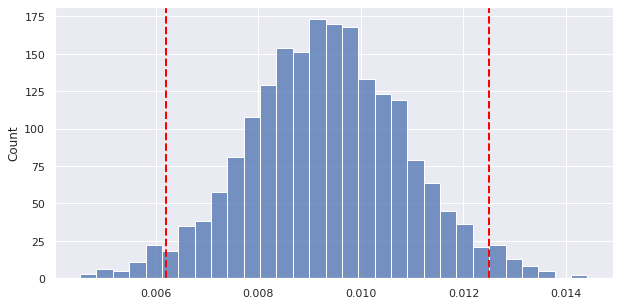

In [23]:
# Разница между глобальными CTR

diff = ctr_control - ctr_test
lower = np.percentile(diff, 2.5)
upper = np.percentile(diff, 97.5)
print(f'95% доверительный интервал: [{lower:.4f}, {upper:.4f}]')
sns.histplot(diff);
plt.axvline(lower, color='red', linestyle='--', linewidth=2);
plt.axvline(upper, color='red', linestyle='--', linewidth=2);

In [33]:
# Бакетное преобразование

q2 = """

SELECT exp_group, bucket,
    sum(likes)/sum(views) as bucket_ctr,
    quantileExact(0.9)(ctr) as ctr9
FROM (SELECT exp_group, 
        xxHash64(user_id)%50 as bucket,
        user_id,
        sum(action = 'like') as likes,
        sum(action = 'view') as views,
        likes/views as ctr
    FROM {db}.feed_actions 
    WHERE toDate(time) between '2026-07-31' and '2026-08-06'
        and exp_group in (1,2)
    GROUP BY exp_group, bucket, user_id)
GROUP BY exp_group, bucket
"""

df2 = ph.read_clickhouse(q2, connection=connection)

In [35]:
# Т-тест

stats.ttest_ind(df2[df2.exp_group == 1].bucket_ctr, 
                   df2[df2.exp_group == 2].bucket_ctr, 
                   equal_var = False)

Ttest_indResult(statistic=5.614819358149381, pvalue=4.592644937473873e-07)

In [36]:
# Тест Манна-Уитни
stats.mannwhitneyu(df2[df2.exp_group == 1].bucket_ctr, 
                   df2[df2.exp_group == 2].bucket_ctr, 
                   alternative = 'two-sided')

MannwhitneyuResult(statistic=1997.0, pvalue=2.6576427804010095e-07)

Тесты поверх бакетного преобразования показали статистически значимую разницу. 
Нулевую гипотезу о равенстве групп отвергаем.

Итоги:  
    Т-тест на изначальной выборке и сглаженных CTR не обнаружил статистически значимую разницу т.к. распределение тестовой группы ассиметричное и сильно скошено.  
    Тест Манна-Уитни, бутстрап и тесты поверх бакетного преобразования обнаружили статистически значимую разницу между группами т.к. для них не важна нормальность изначальной выборки.  
    Расчёт медианных значений CTR показал падение метрики на 33% в тестовой группе. Визуально по распределению можно утверждать, что новая система алгоритмов для одной части пользователей улучшила CTR, а для другой ухудшила.

Возможные причины:
1) Алгоритм по-разному влияет на разные сегменты пользователей. Предпологаю, что для какой-то части пользователей предлагаемый контент стал нерелевантным.
2) В первые дни эксперимента пользователи могли кликать больше т.к. контент казался новым. Эксперимент длился всего неделю и эти первые дни "шума" могли значительно повлиять на результаты.

Рекомендации:  
1) Раскатывать изменение не стоит, падение CTR значительное.  
2) Провести дополнительное исследование о влиянии нового алгоритма на разные сегменты пользователей.  
3) Проверить влияние нового алгоритма на другие важные метрики (Например Retention или LTV).
4) Провести эксперимент на более длительном времени. Проверить рас